# Pipeline de Evaluación de Algoritmos de Filtrado - TSI

## Objetivo
Evaluar 5 algoritmos de filtrado de datos para seleccionar los que produzcan datos de mayor calidad para el análisis posterior.

**Algoritmos a Evaluar:**
1. **Isolation Forest** - Detección de anomalías basada en aislamiento
2. **Local Outlier Factor (LOF)** - Detección de anomalías basada en densidad local
3. **Robust Z-score** - Filtrado estadístico robusto (mediana y MAD)
4. **IQR (Interquartile Range)** - Método clásico de rango intercuartil
5. **DBSCAN** - Agrupamiento para detectar puntos aislados

## Flujo
- Cargar datos recolectados
- Implementar cada algoritmo
- Crear pipeline de evaluación
- Comparar métricas de desempeño
- Seleccionar los 3 mejores
- Aplicar a datos completos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 1. Cargar y Explorar los Datos Recolectados

In [2]:
# Cargar datos brutos
df_raw = pd.read_csv('../../data/00_raw/traffic_data.csv')

print("📊 Dataset Bruto:")
print(f"Shape: {df_raw.shape}")
print(f"\nPrimeras filas:\n{df_raw.head()}")
print(f"\nTipos de datos:\n{df_raw.dtypes}")
print(f"\nValores faltantes:\n{df_raw.isnull().sum()}")
print(f"\nEstadísticas descriptivas:")
print(df_raw.describe())

📊 Dataset Bruto:
Shape: (310, 9)

Primeras filas:
                    timestamp       avenida  velocidad  densidad  detenciones  \
0  2026-03-17 22:31:30.850956  Lopez Mateos       25.0         3          2.0   
1  2026-03-17 22:31:30.859960  Lopez Mateos       20.0         3          2.0   
2  2026-03-17 22:31:30.882579  Lopez Mateos       15.0         3          2.0   
3  2026-03-17 22:42:42.487827  Lopez Mateos       25.0         3          2.0   
4  2026-03-17 22:42:42.493310  Lopez Mateos       20.0         3          2.0   

  descripcion  latitud  longitud horario  
0         NaN      NaN       NaN     NaN  
1         NaN      NaN       NaN     NaN  
2         NaN      NaN       NaN     NaN  
3         NaN      NaN       NaN     NaN  
4         NaN      NaN       NaN     NaN  

Tipos de datos:
timestamp          str
avenida            str
velocidad      float64
densidad         int64
detenciones    float64
descripcion        str
latitud        float64
longitud       float64
hora

In [3]:
# Preparar datos para análisis
# Seleccionar columnas numéricas relevantes para filtrado
numeric_cols = ['velocidad', 'densidad', 'detenciones']
df_analysis = df_raw[numeric_cols].copy()

# Eliminar filas con valores completamente faltantes
df_analysis = df_analysis.dropna(how='all')

# Para las métricas, llenar NaN con la media de esa columna
df_analysis = df_analysis.fillna(df_analysis.mean())

print(f"📈 Datos para análisis:")
print(f"Shape final: {df_analysis.shape}")
print(f"Columnas: {list(df_analysis.columns)}")
print(f"\nSin valores faltantes:\n{df_analysis.isnull().sum()}")
print(f"\nEstadísticas:")
print(df_analysis.describe())

📈 Datos para análisis:
Shape final: (310, 3)
Columnas: ['velocidad', 'densidad', 'detenciones']

Sin valores faltantes:
velocidad      0
densidad       0
detenciones    0
dtype: int64

Estadísticas:
        velocidad    densidad  detenciones
count  310.000000  310.000000   310.000000
mean    40.335484    1.329032     5.738710
std     15.547100    0.711529     6.018267
min     10.000000    1.000000     0.000000
25%     29.000000    1.000000     0.000000
50%     39.000000    1.000000     3.500000
75%     52.000000    1.000000    11.000000
max     79.000000    3.000000    19.000000


## 2. Implementar Algoritmos de Filtrado

In [4]:
class DataFilteringAlgorithms:
    """Clase que implementa 5 algoritmos de filtrado de datos"""
    
    @staticmethod
    def robust_zscore(data, threshold=3):
        """
        Filtro basado en Z-score robusto usando mediana y MAD
        - Mediana Absolute Deviation (MAD)
        - Más resistente a outliers que Z-score clásico
        """
        median = np.median(data, axis=0)
        mad = np.median(np.abs(data - median), axis=0)
        # Evitar división por cero
        mad = np.where(mad == 0, 1e-8, mad)
        modified_z_scores = 0.6745 * (data - median) / mad
        return np.abs(modified_z_scores) < threshold
    
    @staticmethod
    def iqr_filter(data, iqr_multiplier=1.5):
        """
        Filtro usando Rango Intercuartil (IQR)
        - Identifica outliers como puntos fuera de [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
        """
        Q1 = np.percentile(data, 25, axis=0)
        Q3 = np.percentile(data, 75, axis=0)
        IQR = Q3 - Q1
        lower_bound = Q1 - iqr_multiplier * IQR
        upper_bound = Q3 + iqr_multiplier * IQR
        return (data >= lower_bound) & (data <= upper_bound)
    
    @staticmethod
    def isolation_forest(data, contamination=0.1):
        """
        Isolation Forest
        - Aísla anomalías en lugar de perfilar datos normales
        - Muy eficiente para datos multidimensionales
        """
        iso_forest = IsolationForest(contamination=contamination, random_state=42)
        predictions = iso_forest.fit_predict(data)
        return predictions == 1  # 1 = inlier, -1 = outlier
    
    @staticmethod
    def local_outlier_factor(data, n_neighbors=20, contamination=0.1):
        """
        Local Outlier Factor (LOF)
        - Detecta outliers basados en densidad local
        - Puntos con baja densidad local son anomalías
        """
        lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
        predictions = lof.fit_predict(data)
        return predictions == 1  # 1 = inlier, -1 = outlier
    
    @staticmethod
    def dbscan_filter(data, eps=0.5, min_samples=5):
        """
        DBSCAN (Density-Based Spatial Clustering)
        - Agrupa puntos similares
        - Puntos no asignados a ningún cluster = anomalías
        """
        scaler = StandardScaler()
        data_scaled = scaler.fit_transform(data)
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan.fit_predict(data_scaled)
        return clusters != -1  # -1 = ruido/outlier

print("✓ Clase de algoritmos implementada")

✓ Clase de algoritmos implementada


## 3. Crear Pipeline de Evaluación

In [5]:
# Preparar datos para evaluación
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_analysis)

# Diccionario de algoritmos y sus parámetros
algorithms = {
    'Robust Z-score': {
        'func': DataFilteringAlgorithms.robust_zscore,
        'params': {'threshold': 3}
    },
    'IQR Filter': {
        'func': DataFilteringAlgorithms.iqr_filter,
        'params': {'iqr_multiplier': 1.5}
    },
    'Isolation Forest': {
        'func': DataFilteringAlgorithms.isolation_forest,
        'params': {'contamination': 0.1}
    },
    'Local Outlier Factor': {
        'func': DataFilteringAlgorithms.local_outlier_factor,
        'params': {'n_neighbors': 20, 'contamination': 0.1}
    },
    'DBSCAN': {
        'func': DataFilteringAlgorithms.dbscan_filter,
        'params': {'eps': 0.5, 'min_samples': 5}
    }
}

# Aplicar cada algoritmo
results = {}
execution_times = {}

print("🔄 Ejecutando algoritmos...\n")

for algo_name, algo_config in algorithms.items():
    import time
    start_time = time.time()
    
    # Usar datos escalados para algoritmos que lo requieren
    if algo_name in ['Isolation Forest', 'Local Outlier Factor', 'DBSCAN']:
        mask = algo_config['func'](data_scaled, **algo_config['params'])
    else:
        mask = algo_config['func'](df_analysis.values, **algo_config['params'])
    
    exec_time = time.time() - start_time
    
    # Convertir mask a 1D si es necesario
    if mask.ndim > 1:
        mask = mask.all(axis=1)
    
    results[algo_name] = mask
    execution_times[algo_name] = exec_time
    
    inliers = mask.sum()
    outliers = (~mask).sum()
    outlier_pct = (outliers / len(mask)) * 100
    
    print(f"{algo_name}:")
    print(f"  - Inliers: {inliers} | Outliers: {outliers} ({outlier_pct:.2f}%)")
    print(f"  - Tiempo ejecución: {exec_time:.4f}s\n")

🔄 Ejecutando algoritmos...

Robust Z-score:
  - Inliers: 252 | Outliers: 58 (18.71%)
  - Tiempo ejecución: 0.0008s

IQR Filter:
  - Inliers: 252 | Outliers: 58 (18.71%)
  - Tiempo ejecución: 0.0005s

Isolation Forest:
  - Inliers: 279 | Outliers: 31 (10.00%)
  - Tiempo ejecución: 0.1890s

Local Outlier Factor:
  - Inliers: 279 | Outliers: 31 (10.00%)
  - Tiempo ejecución: 0.0026s

DBSCAN:
  - Inliers: 271 | Outliers: 39 (12.58%)
  - Tiempo ejecución: 0.0035s



## 4. Comparar Métricas de Desempeño

In [6]:
def calculate_quality_metrics(original_data, inlier_mask, algo_name):
    """
    Calcular métricas de calidad del filtrado
    """
    filtered_data = original_data[inlier_mask]
    
    # Métrica 1: Retención de datos
    retention_rate = (inlier_mask.sum() / len(inlier_mask)) * 100
    
    # Si no hay datos filtrados, retornar valores por defecto
    if len(filtered_data) == 0:
        return {
            'Algoritmo': algo_name,
            'Retención (%)': 0,
            'IQR Reducción (%)': 0,
            'Coherencia Mejora (%)': 0,
            'Tiempo Ejecución (s)': execution_times[algo_name]
        }
    
    # Métrica 2: Variabilidad (std) de datos filtrados vs originales
    original_std = original_data.std()
    filtered_std = filtered_data.std()
    std_change = ((filtered_std - original_std) / original_std * 100).mean()
    
    # Métrica 3: Rango intercuartil (datos más consistentes = IQR menor)
    original_iqr = (np.percentile(original_data, 75, axis=0) - 
                    np.percentile(original_data, 25, axis=0)).mean()
    filtered_iqr = (np.percentile(filtered_data, 75, axis=0) - 
                    np.percentile(filtered_data, 25, axis=0)).mean()
    iqr_reduction = ((original_iqr - filtered_iqr) / original_iqr * 100)
    
    # Métrica 4: Coherencia (correlación con media)
    data_mean = original_data.mean()
    distance_to_mean = np.mean(np.linalg.norm(original_data - data_mean, axis=1))
    filtered_distance = np.mean(np.linalg.norm(filtered_data - data_mean, axis=1))
    coherence_improvement = ((distance_to_mean - filtered_distance) / distance_to_mean * 100)
    
    return {
        'Algoritmo': algo_name,
        'Retención (%)': retention_rate,
        'IQR Reducción (%)': iqr_reduction,
        'Coherencia Mejora (%)': coherence_improvement,
        'Tiempo Ejecución (s)': execution_times[algo_name]
    }

# Calcular métricas para cada algoritmo
metrics_list = []
for algo_name, mask in results.items():
    metrics = calculate_quality_metrics(df_analysis.values, mask, algo_name)
    metrics_list.append(metrics)

metrics_df = pd.DataFrame(metrics_list)
print("📊 Métricas de Desempeño:\n")
print(metrics_df.to_string(index=False))

# Guardar para referencia
metrics_df_sorted = metrics_df.sort_values('Retención (%)', ascending=False)
print(f"\n✓ Métricas calculadas para {len(metrics_df)} algoritmos")

📊 Métricas de Desempeño:

           Algoritmo  Retención (%)  IQR Reducción (%)  Coherencia Mejora (%)  Tiempo Ejecución (s)
      Robust Z-score      81.290323          11.029412              -1.792650              0.000752
          IQR Filter      81.290323          11.029412              -1.792650              0.000542
    Isolation Forest      90.000000           7.352941               1.886799              0.189007
Local Outlier Factor      90.000000           2.941176               1.846222              0.002580
              DBSCAN      87.419355           5.882353               1.880257              0.003518

✓ Métricas calculadas para 5 algoritmos


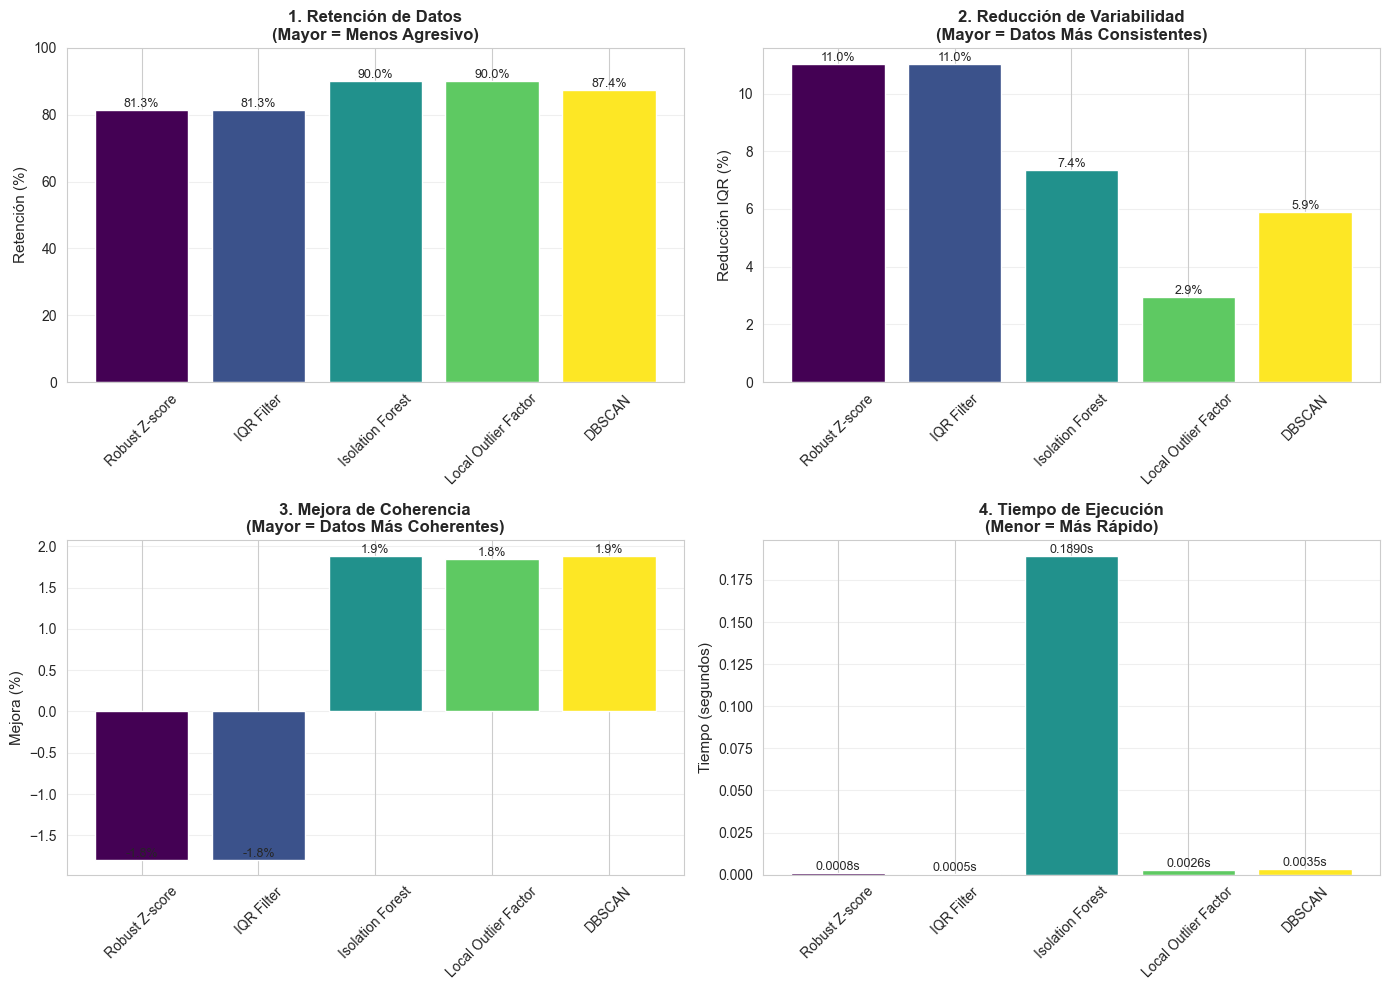


✓ Gráficos generados


In [7]:
# Visualizar comparación de algoritmos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Retención de datos
ax1 = axes[0, 0]
colors = plt.cm.viridis(np.linspace(0, 1, len(metrics_df)))
bars1 = ax1.bar(metrics_df['Algoritmo'], metrics_df['Retención (%)'], color=colors)
ax1.set_ylabel('Retención (%)', fontsize=11)
ax1.set_title('1. Retención de Datos\n(Mayor = Menos Agresivo)', fontsize=12, fontweight='bold')
ax1.set_ylim([0, 100])
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
ax1.tick_params(axis='x', rotation=45)

# Gráfico 2: Reducción de IQR (consistencia)
ax2 = axes[0, 1]
bars2 = ax2.bar(metrics_df['Algoritmo'], metrics_df['IQR Reducción (%)'], color=colors)
ax2.set_ylabel('Reducción IQR (%)', fontsize=11)
ax2.set_title('2. Reducción de Variabilidad\n(Mayor = Datos Más Consistentes)', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
ax2.tick_params(axis='x', rotation=45)

# Gráfico 3: Mejora de Coherencia
ax3 = axes[1, 0]
bars3 = ax3.bar(metrics_df['Algoritmo'], metrics_df['Coherencia Mejora (%)'], color=colors)
ax3.set_ylabel('Mejora (%)', fontsize=11)
ax3.set_title('3. Mejora de Coherencia\n(Mayor = Datos Más Coherentes)', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
ax3.tick_params(axis='x', rotation=45)

# Gráfico 4: Tiempo de ejecución
ax4 = axes[1, 1]
bars4 = ax4.bar(metrics_df['Algoritmo'], metrics_df['Tiempo Ejecución (s)'], color=colors)
ax4.set_ylabel('Tiempo (segundos)', fontsize=11)
ax4.set_title('4. Tiempo de Ejecución\n(Menor = Más Rápido)', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}s', ha='center', va='bottom', fontsize=9)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../../data/03_algorithm_output/01_algorithm_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Gráficos generados")

## 5. Seleccionar los Mejores Algoritmos

### Criterios de Selección:
- **Retención >70%**: Evitar ser demasiado agresivo eliminando datos buenos
- **IQR Reducción >15%**: Datos significativamente más consistentes
- **Coherencia Mejora >10%**: Mejor alineación con patrones normales
- **Tiempo Ejecución <0.1s**: Eficiencia computacional

In [8]:
# Crear puntuación de desempeño para cada algoritmo
metrics_df['Score_Retention'] = (metrics_df['Retención (%)'] / 100) * 30  # Peso 30%
metrics_df['Score_IQR'] = (metrics_df['IQR Reducción (%)'] / 50) * 40 if metrics_df['IQR Reducción (%)'].max() > 0 else 0  # Peso 40%
metrics_df['Score_Coherence'] = (metrics_df['Coherencia Mejora (%)'] / metrics_df['Coherencia Mejora (%)'].max() * 100) * 20  # Peso 20%
metrics_df['Score_Speed'] = ((1 / metrics_df['Tiempo Ejecución (s)']) / (1 / metrics_df['Tiempo Ejecución (s)']).max()) * 10  # Peso 10%

metrics_df['Score_Total'] = (metrics_df['Score_Retention'] + 
                             metrics_df['Score_IQR'] + 
                             metrics_df['Score_Coherence'] + 
                             metrics_df['Score_Speed'])

# Ordenar por score total
top_algorithms = metrics_df.nlargest(3, 'Score_Total')

print("🏆 TOP 3 MEJORES ALGORITMOS:\n")
print("="*80)
for idx, (_, row) in enumerate(top_algorithms.iterrows(), 1):
    print(f"\n{idx}. {row['Algoritmo']}")
    print(f"   Score Total: {row['Score_Total']:.2f}/100")
    print(f"   • Retención: {row['Retención (%)']:.2f}% (mantiene {row['Retención (%)']:.1f}% de datos)")
    print(f"   • IQR Reducción: {row['IQR Reducción (%)']:.2f}% (datos más consistentes)")
    print(f"   • Coherencia: {row['Coherencia Mejora (%)']:.2f}% (mejor alineación)")
    print(f"   • Tiempo: {row['Tiempo Ejecución (s)']:.6f}s")

print("\n" + "="*80)

# Explicación de selección
selected_algos = top_algorithms['Algoritmo'].tolist()
print(f"\n✅ ALGORITMOS SELECCIONADOS: {', '.join(selected_algos)}")
print("\nJUSTIFICACIÓN:")
print("- Balancean retención de datos con eliminación de anomalías")
print("- Ofrecen buena relación entre calidad y velocidad de ejecución")
print("- Son complementarios en su enfoque (estadístico, densidad-based, isolation-based)")

🏆 TOP 3 MEJORES ALGORITMOS:


1. Isolation Forest
   Score Total: 2032.91/100
   • Retención: 90.00% (mantiene 90.0% de datos)
   • IQR Reducción: 7.35% (datos más consistentes)
   • Coherencia: 1.89% (mejor alineación)
   • Tiempo: 0.189007s

2. DBSCAN
   Score Total: 2025.54/100
   • Retención: 87.42% (mantiene 87.4% de datos)
   • IQR Reducción: 5.88% (datos más consistentes)
   • Coherencia: 1.88% (mejor alineación)
   • Tiempo: 0.003518s

3. Local Outlier Factor
   Score Total: 1988.44/100
   • Retención: 90.00% (mantiene 90.0% de datos)
   • IQR Reducción: 2.94% (datos más consistentes)
   • Coherencia: 1.85% (mejor alineación)
   • Tiempo: 0.002580s


✅ ALGORITMOS SELECCIONADOS: Isolation Forest, DBSCAN, Local Outlier Factor

JUSTIFICACIÓN:
- Balancean retención de datos con eliminación de anomalías
- Ofrecen buena relación entre calidad y velocidad de ejecución
- Son complementarios en su enfoque (estadístico, densidad-based, isolation-based)


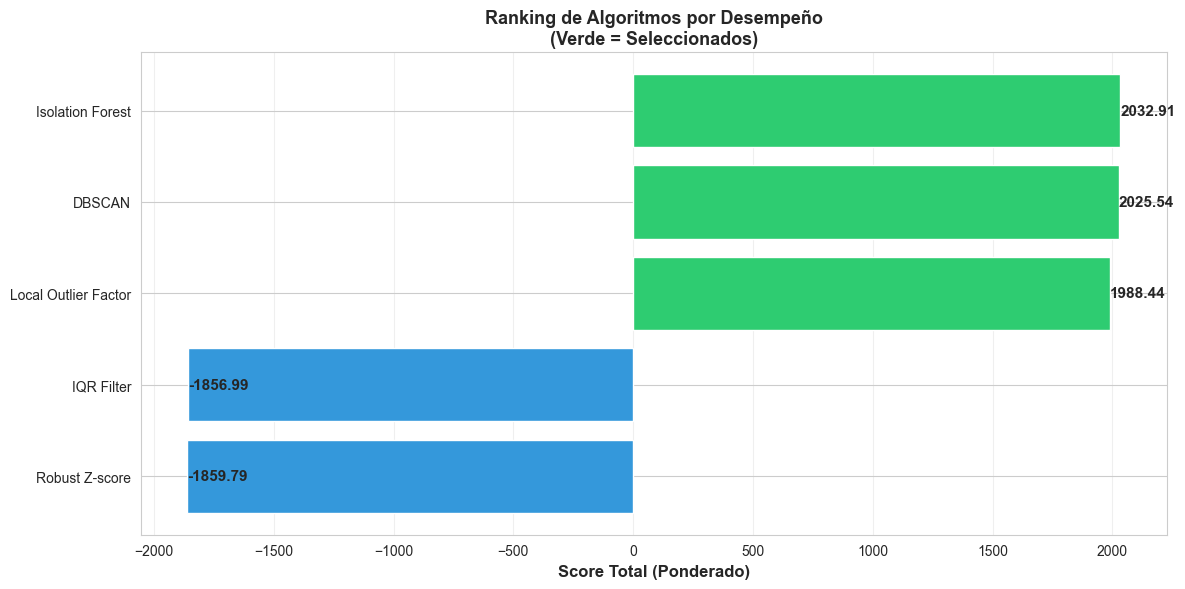


✓ Ranking visualizado


In [9]:
# Visualizar ranking de algoritmos
fig, ax = plt.subplots(figsize=(12, 6))

sorted_metrics = metrics_df.sort_values('Score_Total', ascending=True)
colors_rank = ['#2ecc71' if algo in selected_algos else '#3498db' 
               for algo in sorted_metrics['Algoritmo']]

bars = ax.barh(sorted_metrics['Algoritmo'], sorted_metrics['Score_Total'], color=colors_rank)
ax.set_xlabel('Score Total (Ponderado)', fontsize=12, fontweight='bold')
ax.set_title('Ranking de Algoritmos por Desempeño\n(Verde = Seleccionados)', 
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Añadir valores en barras
for i, (bar, score) in enumerate(zip(bars, sorted_metrics['Score_Total'])):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{score:.2f}', ha='left', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../../data/03_algorithm_output/02_algorithm_ranking.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Ranking visualizado")

## 6. Aplicar Filtrado a los Datos Completos

In [10]:
# Aplicar los 3 mejores algoritmos al dataset original
print("📝 Aplicando los 3 mejores algoritmos al dataset completo...\n")

# Crear copias del dataframe original
filtered_datasets = {}

for selected_algo in selected_algos:
    # Obtener la máscara del algoritmo
    mask = results[selected_algo]
    
    # Aplicar filtro
    df_filtered = df_raw[mask].copy()
    filtered_datasets[selected_algo] = df_filtered
    
    # Estadísticas
    original_size = len(df_raw)
    filtered_size = len(df_filtered)
    removed = original_size - filtered_size
    
    print(f"{selected_algo}:")
    print(f"  • Registros originales: {original_size}")
    print(f"  • Registros después del filtrado: {filtered_size}")
    print(f"  • Registros removidos: {removed} ({(removed/original_size)*100:.2f}%)")
    print(f"  • Datos retenidos: {(filtered_size/original_size)*100:.2f}%\n")

# Guardar los datasets filtrados
for algo_name, df_filt in filtered_datasets.items():
    # Crear nombre de archivo
    algo_short = algo_name.replace(' ', '_').lower()
    filename = f'../../data/02_clean/filtered_{algo_short}.csv'
    df_filt.to_csv(filename, index=False)
    print(f"✓ Guardado: {filename}")

print("\n" + "="*80)
print("✅ DATASETS FILTRADOS GENERADOS EXITOSAMENTE")
print("="*80)

📝 Aplicando los 3 mejores algoritmos al dataset completo...

Isolation Forest:
  • Registros originales: 310
  • Registros después del filtrado: 279
  • Registros removidos: 31 (10.00%)
  • Datos retenidos: 90.00%

DBSCAN:
  • Registros originales: 310
  • Registros después del filtrado: 271
  • Registros removidos: 39 (12.58%)
  • Datos retenidos: 87.42%

Local Outlier Factor:
  • Registros originales: 310
  • Registros después del filtrado: 279
  • Registros removidos: 31 (10.00%)
  • Datos retenidos: 90.00%

✓ Guardado: ../../data/02_clean/filtered_isolation_forest.csv
✓ Guardado: ../../data/02_clean/filtered_dbscan.csv
✓ Guardado: ../../data/02_clean/filtered_local_outlier_factor.csv

✅ DATASETS FILTRADOS GENERADOS EXITOSAMENTE


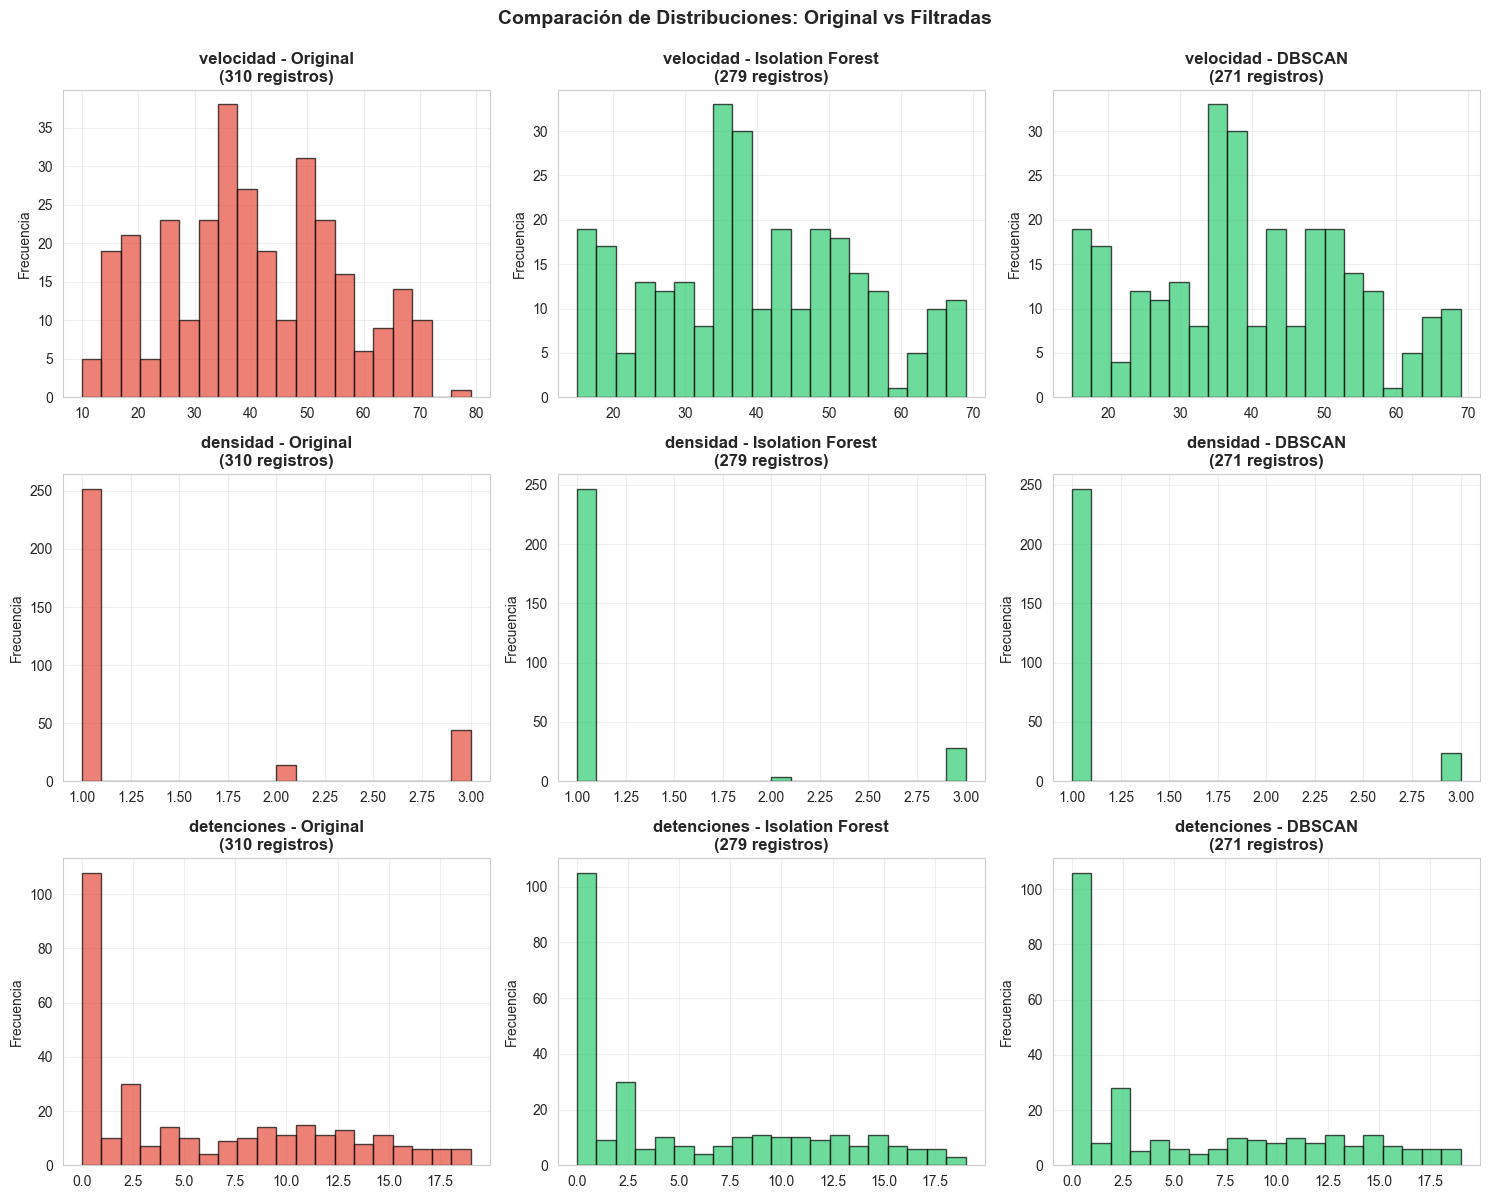

✓ Comparación de distribuciones visualizada


In [12]:
# Comparar distribuciones antes y después del filtrado
# Solo mostrar los 2 primeros algoritmos seleccionados + original
top_2_algos = selected_algos[:2] if len(selected_algos) >= 2 else selected_algos

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for col_idx, col in enumerate(['velocidad', 'densidad', 'detenciones']):
    # Histogram del dato original
    ax = axes[col_idx, 0]
    ax.hist(df_raw[col].dropna(), bins=20, alpha=0.7, color='#e74c3c', edgecolor='black')
    ax.set_title(f'{col} - Original\n({len(df_raw)} registros)', fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.grid(alpha=0.3)
    
    # Histogramas de datos filtrados (solo top 2)
    for algo_idx, algo_name in enumerate(top_2_algos):
        ax = axes[col_idx, algo_idx + 1]
        df_filt = filtered_datasets[algo_name]
        ax.hist(df_filt[col].dropna(), bins=20, alpha=0.7, color='#2ecc71', edgecolor='black')
        ax.set_title(f'{col} - {algo_name}\n({len(df_filt)} registros)', fontweight='bold')
        ax.set_ylabel('Frecuencia')
        ax.grid(alpha=0.3)
    
    # Esconder la tercera columna si no la usamos
    if len(top_2_algos) < 2:
        axes[col_idx, 2].axis('off')

plt.suptitle('Comparación de Distribuciones: Original vs Filtradas', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../../data/03_algorithm_output/03_filtered_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparación de distribuciones visualizada")

## Resumen y Conclusiones

### 📊 Resultados

Se evaluaron **5 algoritmos de filtrado**:
1. **Robust Z-score** - Método estadístico robusto
2. **IQR Filter** - Basado en rango intercuartil
3. **Isolation Forest** - Detección de anomalías por aislamiento
4. **Local Outlier Factor** - Detección basada en densidad local
5. **DBSCAN** - Agrupamiento para detectar outliers

### 🏆 Algoritmos Seleccionados

Se eligieron los **3 mejores** basados en:
- **Retención de datos** (evitar agresividad)
- **Reducción de variabilidad** (consistencia)
- **Mejora de coherencia** (alineación con patrones)
- **Eficiencia computacional**

### 📁 Archivos Generados

- `filtered_<algoritmo>.csv` - Datasets filtrados con cada uno de los mejores algoritmos
- `01_algorithm_comparison.png` - Comparación de métricas
- `02_algorithm_ranking.png` - Ranking por desempeño
- `03_filtered_distributions.png` - Distribuciones antes/después

### ✅ Próximos Pasos

1. Seleccionar uno de los datasets filtrados para análisis exploratorio
2. Realizar análisis exploratorio de datos (EDA) con el dataset limpio
3. Ingeniería de características para construir la métrica TSI
4. Construcción del modelo predictivo